# 03 — Binary Classification Filter (DR vs No-DR)
**Dataset:** Diabetic Retinopathy Resized (`tanlikesmath/diabetic-retinopathy-resized`)
**Goal:** Download via KaggleHub, preprocess fundus images with DR grade labels, save **train split only** as `.npz` (224×224), analyze class distribution.
> Run on **Google Colab** with T4 GPU. Set your Kaggle credentials in **Colab Secrets** before running.
> ⚡ **Storage-optimized:** images resized to 224×224 and only the train split is saved to Drive (~500MB total).

## 1. Colab Repo Setup

In [2]:
import os
from pathlib import Path

repo_path = Path('/content/DRP_segmentation')
if not repo_path.exists():
    !git clone https://github.com/engMohamedAbdAlslam/DRP_segmentation.git /content/DRP_segmentation

%cd /content/DRP_segmentation
!git checkout copilot/develop-preprocessing-pipeline
!git pull origin copilot/develop-preprocessing-pipeline
print('Repo ready at', Path.cwd())

Cloning into '/content/DRP_segmentation'...
remote: Enumerating objects: 251, done.
remote: Counting objects: 100% (251/251), done.
remote: Compressing objects: 100% (178/178), done.
remote: Total 251 (delta 127), reused 162 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (251/251), 3.02 MiB | 16.83 MiB/s, done.
Resolving deltas: 100% (127/127), done.
/content/DRP_segmentation
Branch 'copilot/develop-preprocessing-pipeline' set up to track remote branch 'copilot/develop-preprocessing-pipeline' from 'origin'.
Switched to a new branch 'copilot/develop-preprocessing-pipeline'
From https://github.com/engMohamedAbdAlslam/DRP_segmentation
 * branch            copilot/develop-preprocessing-pipeline -> FETCH_HEAD
Already up to date.
Repo ready at /content/DRP_segmentation


## 2. Install Dependencies

In [3]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                'kagglehub', 'opencv-python-headless', 'tqdm', 'matplotlib', 'scikit-learn', 'numpy', 'pandas'],
               check=True)
print('Dependencies ready.')

Dependencies ready.


## 3. Kaggle Authentication

In [4]:
from google.colab import userdata
import os, json

try:
    token_raw = userdata.get('KAGGLE_TOKEN')
    if token_raw and token_raw.strip().startswith('{'):
        kaggle_token = json.loads(token_raw)
        os.environ['KAGGLE_USERNAME'] = kaggle_token['username']
        os.environ['KAGGLE_KEY']      = kaggle_token['key']
    else:
        os.environ['KAGGLE_KEY']      = token_raw
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
except Exception:
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

assert os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'), \
    'Kaggle credentials missing!'
print(f"Kaggle ready ✔ user: {os.environ['KAGGLE_USERNAME']}")

Kaggle ready ✔ user: zainalabidinshbani


## 4. Imports & Path Setup

In [5]:
import sys, shutil
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

print('numpy', np.__version__)
print('opencv', cv2.__version__)

repo_root = Path('/content/DRP_segmentation')
if str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))

from engine.image_preprocessing import PreprocessConfig, preprocess_fundus_image, save_preprocessed

data_dir      = repo_root / 'data'
raw_dir       = data_dir / 'raw'
processed_dir = data_dir / 'processed'
raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

# Storage config
TARGET_SIZE   = (224, 224)   # 16x smaller than 512x512
SAVE_SPLITS   = ['train']    # val/test loaded on-the-fly during training
print(f'Target size: {TARGET_SIZE} | Saving splits: {SAVE_SPLITS}')

numpy 2.0.2
opencv 4.13.0
Target size: (224, 224) | Saving splits: ['train']


## 5. Download DR Resized Dataset

In [6]:
import kagglehub

DATASET_SLUG = 'tanlikesmath/diabetic-retinopathy-resized'
DATASET_NAME = 'dr_resized'
dr_root      = raw_dir / 'dr_resized'
dr_root.mkdir(parents=True, exist_ok=True)

already_downloaded = any(dr_root.rglob('*.png')) or any(dr_root.rglob('*.jpeg')) or any(dr_root.rglob('*.csv'))
if not already_downloaded:
    print(f'Downloading {DATASET_SLUG} ...')
    download_path = Path(kagglehub.dataset_download(DATASET_SLUG))
    shutil.copytree(str(download_path), str(dr_root), dirs_exist_ok=True)
    print('Download complete:', dr_root)
else:
    print('Dataset already present at:', dr_root)

all_files = list(dr_root.rglob('*'))
print(f'Total items: {len(all_files)}')
for f in all_files[:20]: print(f)

100%|██████████| 7.25G/7.25G [01:28<00:00, 87.9MB/s]

Extracting files...


Download complete: /content/DRP_segmentation/data/raw/dr_resized
Total items: 70240
/content/DRP_segmentation/data/raw/dr_resized/trainLabels.csv
/content/DRP_segmentation/data/raw/dr_resized/resized_train_cropped
/content/DRP_segmentation/data/raw/dr_resized/resized_train
/content/DRP_segmentation/data/raw/dr_resized/trainLabels_cropped.csv
/content/DRP_segmentation/data/raw/dr_resized/resized_train_cropped/resized_train_cropped
/content/DRP_segmentation/data/raw/dr_resized/resized_train/resized_train
/content/DRP_segmentation/data/raw/dr_resized/resized_train_cropped/resized_train_cropped/19378_right.jpeg
/content/DRP_segmentation/data/raw/dr_resized/resized_train_cropped/resized_train_cropped/37986_left.jpeg
/content/DRP_segmentation/data/raw/dr_resized/resized_train_cropped/resized_train_cropped/30299_right.jpeg
/content/DRP_segmentation/data/raw/dr_resized/resized_train_cropped/resized_train_cropped/29174_left.jpeg
/content/DRP_segmentation/data/raw/dr_resized/resized_train_croppe

## 6. Load Labels & Index Images

In [7]:

import os
print("=== Folder structure ===")
for root, dirs, files in os.walk(dr_root):
    level = str(root).replace(str(dr_root), '').count(os.sep)
    if level < 3:
        print('  ' * level + os.path.basename(root) + '/')
        for f in files[:3]:
            print('  ' * (level+1) + f)

print("\n=== Image extensions found ===")
exts = {}
for p in dr_root.rglob('*'):
    if p.is_file():
        exts[p.suffix.lower()] = exts.get(p.suffix.lower(), 0) + 1
print(exts)

=== Folder structure ===
dr_resized/
  trainLabels.csv
  trainLabels_cropped.csv
  resized_train_cropped/
    resized_train_cropped/
      19378_right.jpeg
      37986_left.jpeg
      30299_right.jpeg
  resized_train/
    resized_train/
      19378_right.jpeg
      37986_left.jpeg
      30299_right.jpeg

=== Image extensions found ===
{'.csv': 2, '.jpeg': 70234}


In [8]:
IMAGE_EXTS     = {'.png', '.jpg', '.jpeg'}
DR_GRADE_NAMES = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative'}


img_dir = dr_root / 'resized_train_cropped' / 'resized_train_cropped'
label_csv = dr_root / 'trainLabels_cropped.csv'

raw_df  = pd.read_csv(label_csv)
img_col = 'image'
lbl_col = 'level'


img_map = {p.stem: p for p in img_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTS}
print(f'Images on disk: {len(img_map)}')
print('Sample stems:', list(img_map.keys())[:3])
print('Sample CSV:  ', raw_df[img_col].tolist()[:3])

rows = []
for _, row in raw_df.iterrows():
    stem     = Path(str(row[img_col])).stem
    img_path = img_map.get(stem)
    if img_path:
        grade = int(row[lbl_col])
        rows.append({'image_path': img_path, 'dr_grade': grade,
                     'binary_label': 0 if grade == 0 else 1})

df = pd.DataFrame(rows)
print(f'\nTotal images indexed: {len(df)}')
if not df.empty:
    print(df['dr_grade'].map(DR_GRADE_NAMES).value_counts().sort_index())

Images on disk: 35108
Sample stems: ['19378_right', '37986_left', '30299_right']
Sample CSV:   ['10_left', '10_right', '13_left']

Total images indexed: 35108
dr_grade
Mild              2438
Moderate          5288
No DR            25802
Proliferative      708
Severe             872
Name: count, dtype: int64


## 7. Train / Val / Test Split (70/15/15) — Stratified

In [9]:
if df is None or df.empty:
    raise RuntimeError('No images found — check dataset download path.')

stratify_col = df['binary_label'] if df['binary_label'].nunique() > 1 else None
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=stratify_col)
s2 = temp_df['binary_label'] if temp_df['binary_label'].nunique() > 1 else None
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=s2)

splits = {'train': train_df, 'val': val_df, 'test': test_df}
for name, sdf in splits.items():
    dist = sdf['binary_label'].value_counts().to_dict()
    print(f'{name}: {len(sdf)} images | No-DR:{dist.get(0,0)} DR:{dist.get(1,0)}')

# Save val/test paths as CSV for on-the-fly loading during training
val_df[['image_path','dr_grade','binary_label']].assign(
    image_path=val_df['image_path'].astype(str)
).to_csv(processed_dir / 'dr_resized_val_index.csv', index=False)
test_df[['image_path','dr_grade','binary_label']].assign(
    image_path=test_df['image_path'].astype(str)
).to_csv(processed_dir / 'dr_resized_test_index.csv', index=False)
print('Val/Test indices saved as CSV (no .npz needed for them).')

train: 24575 images | No-DR:18061 DR:6514
val: 5266 images | No-DR:3870 DR:1396
test: 5267 images | No-DR:3871 DR:1396
Val/Test indices saved as CSV (no .npz needed for them).


## 8. Batch Preprocessing & Save Train Split as .npz
> Only the **train** split is saved as `.npz` (224×224). Val/Test are indexed by CSV and loaded on-the-fly.

In [10]:
config = PreprocessConfig(target_size=TARGET_SIZE, normalization='zero_one')
errors = []

for split_name in SAVE_SPLITS:
    split_df = splits[split_name]
    out_dir  = processed_dir / DATASET_NAME / split_name
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f'\nProcessing {split_name} ({len(split_df)} images) @ {TARGET_SIZE}...')
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=split_name):
        try:
            result   = preprocess_fundus_image(row['image_path'], mask=None, config=config)
            out_file = out_dir / (row['image_path'].stem + f'_grade{row["dr_grade"]}.npz')
            save_preprocessed(result, out_file)
        except Exception as e:
            errors.append({'file': str(row['image_path']), 'error': str(e)})

print(f'\nDone. Errors: {len(errors)}')
if errors:
    print(pd.DataFrame(errors).head(10))

# Estimate saved size
import os
train_out = processed_dir / DATASET_NAME / 'train'
total_mb  = sum(f.stat().st_size for f in train_out.rglob('*.npz')) / 1e6
print(f'\nEstimated train .npz size: {total_mb:.1f} MB')


Processing train (24575 images) @ (224, 224)...


train: 100%|██████████| 24575/24575 [45:07<00:00,  9.08it/s]



Done. Errors: 0

Estimated train .npz size: 3636.3 MB


## 9. Dataset Statistics & Class Distribution

=== Processed .npz Counts (train only) ===
  train: 24575 files


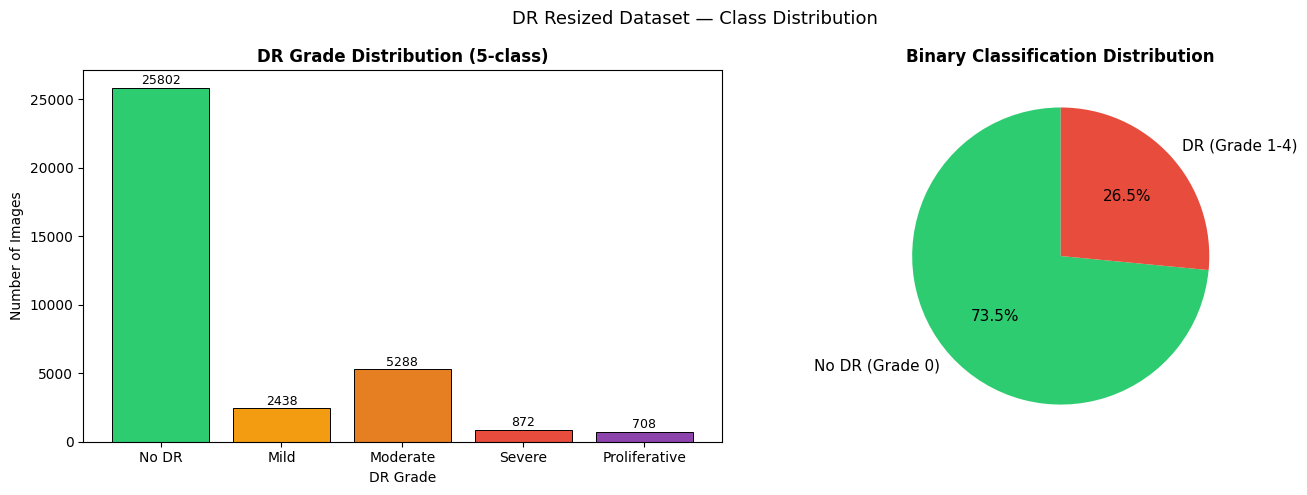


Class imbalance ratio (DR/No-DR): 0.36


In [11]:
print('=== Processed .npz Counts (train only) ===')
count = len(list((processed_dir / DATASET_NAME / 'train').rglob('*.npz')))
print(f'  train: {count} files')

counts  = df['dr_grade'].value_counts().sort_index()
labels  = [DR_GRADE_NAMES.get(i, f'Grade {i}') for i in counts.index]
colors  = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#8e44ad'][:len(counts)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.7)
ax1.set_title('DR Grade Distribution (5-class)', fontsize=12, fontweight='bold')
ax1.set_xlabel('DR Grade'); ax1.set_ylabel('Number of Images')
for i, v in enumerate(counts.values): ax1.text(i, v + max(counts.values)*0.01, str(v), ha='center', fontsize=9)

binary_counts = df['binary_label'].value_counts().sort_index()
ax2.pie(binary_counts.values, labels=['No DR (Grade 0)', 'DR (Grade 1-4)'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 11})
ax2.set_title('Binary Classification Distribution', fontsize=12, fontweight='bold')

plt.suptitle('DR Resized Dataset — Class Distribution', fontsize=13)
plt.tight_layout(); plt.show()
print(f'\nClass imbalance ratio (DR/No-DR): {binary_counts.get(1,0)/max(binary_counts.get(0,1),1):.2f}')

## 10. Visualization — Sample Images per DR Grade

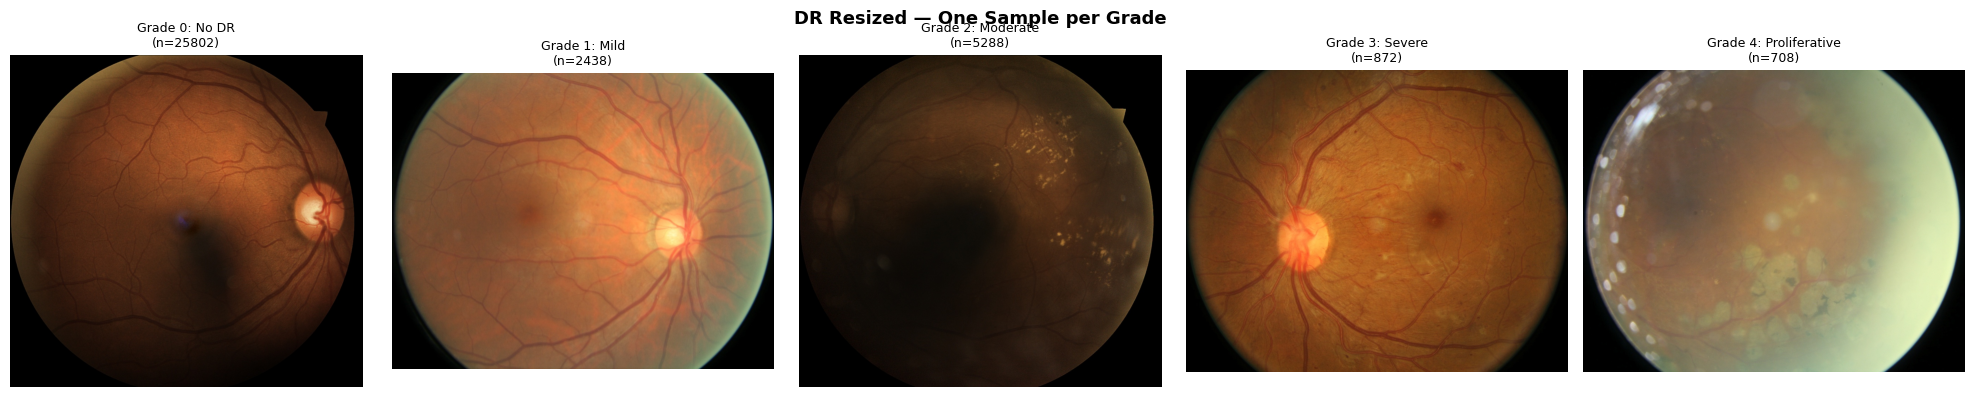

In [12]:
unique_labels = sorted(df['dr_grade'].unique())
n_cols = min(5, len(unique_labels))
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
if n_cols == 1: axes = [axes]

for i, lbl in enumerate(unique_labels):
    subset     = df[df['dr_grade'] == lbl]
    sample_row = subset.sample(1, random_state=42).iloc[0]
    img_bgr    = cv2.imread(str(sample_row['image_path']))
    if img_bgr is not None:
        axes[i].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Grade {lbl}: {DR_GRADE_NAMES.get(lbl,"?")}\n(n={len(subset)})', fontsize=9)
    axes[i].axis('off')

plt.suptitle('DR Resized — One Sample per Grade', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 11. Save Train .npz + CSV Indices to Google Drive
> Saves only train `.npz` files + val/test CSV indices. Total ~500MB.

In [13]:
from google.colab import drive as gdrive
gdrive.mount('/content/drive')

drive_dest = Path('/content/drive/MyDrive/DRP_processed')
drive_dest.mkdir(parents=True, exist_ok=True)

# Copy train .npz only
src_train = processed_dir / DATASET_NAME / 'train'
if src_train.exists():
    shutil.copytree(str(src_train), str(drive_dest / DATASET_NAME / 'train'), dirs_exist_ok=True)
    npz_count = len(list((drive_dest / DATASET_NAME / 'train').rglob('*.npz')))
    print(f'Saved {npz_count} train .npz → {drive_dest / DATASET_NAME / "train"}')
else:
    print('No train .npz found. Run Cell 8 first.')

# Copy val/test CSV indices
for csv_name in ['dr_resized_val_index.csv', 'dr_resized_test_index.csv']:
    src_csv = processed_dir / csv_name
    if src_csv.exists():
        shutil.copy(str(src_csv), str(drive_dest / csv_name))
        print(f'Saved {csv_name} → {drive_dest}')

# Final size estimate
total_mb = sum(f.stat().st_size for f in (drive_dest / DATASET_NAME / 'train').rglob('*.npz')) / 1e6
print(f'\nTotal Drive usage: {total_mb:.1f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved 24575 train .npz → /content/drive/MyDrive/DRP_processed/dr_resized/train
Saved dr_resized_val_index.csv → /content/drive/MyDrive/DRP_processed
Saved dr_resized_test_index.csv → /content/drive/MyDrive/DRP_processed

Total Drive usage: 3636.3 MB


## Next Steps — Model Training
- Load train `.npz` from `DRP_processed/dr_resized/train/` for training
- Load val/test images on-the-fly using the saved CSV indices
- Recommended architecture: **EfficientNet-B4** or **ResNet-50** fine-tuned on fundus images
- Address class imbalance with: **weighted cross-entropy**, **focal loss**, or **oversampling**
- Metrics: **AUC-ROC**, **F1-score**, **Sensitivity**, **Specificity** (clinical priority: high sensitivity)